# FastAI 11-Class Image Classification (3 Model Fine-Tuning)

This notebook does the full pipeline in one place:
1. Clean dataset once from `raw/` into `cleaned/` (corrupt files + duplicates).
2. Fine-tune 3 pre-trained models with consistent settings.
3. Compare models and select the best.
4. Evaluate best model on held-out test split with class-wise metrics.
5. Export model artifacts and run inference demo.

In [ ]:
# Optional installs (uncomment if needed)
# %pip install -q fastai timm scikit-learn seaborn

from fastai.vision.all import *
from fastai.callback.schedule import valley
from torchvision.models import resnet50

try:
    from fastai.vision.learner import timm_learner
except Exception:
    timm_learner = None

import hashlib
import json
import os
import random
import shutil
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
set_seed(42, reproducible=True)
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

RAW_DIR = Path("raw")
CLEANED_DIR = Path("cleaned")
ARTIFACTS_DIR = Path("artifacts")
REPORTS_DIR = Path("reports")

IMG_SIZE = 224
EPOCHS = 15
VALID_PCT = 0.10
TEST_PCT = 0.10
RANDOM_SEED = 42
FORCE_RECLEAN = False

def suggest_batch_size(img_size: int = 224):
    if not torch.cuda.is_available():
        return 8, "cpu"

    total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    if total_mem_gb >= 20:
        return 64, f"gpu_{total_mem_gb:.1f}GB"
    if total_mem_gb >= 11:
        return 32, f"gpu_{total_mem_gb:.1f}GB"
    if total_mem_gb >= 7:
        return 16, f"gpu_{total_mem_gb:.1f}GB"
    return 8, f"gpu_{total_mem_gb:.1f}GB"

BS, HW_PROFILE = suggest_batch_size(img_size=IMG_SIZE)

# Tuned defaults for product-image style datasets: modest geometric distortion + stronger lighting jitter.
AUG_MULT = 0.9
AUG_MAX_ROTATE = 8.0
AUG_MAX_ZOOM = 1.08
AUG_MAX_WARP = 0.08
AUG_P_AFFINE = 0.75
AUG_P_LIGHTING = 0.80

assert RAW_DIR.exists(), f"Missing input folder: {RAW_DIR.resolve()}"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw dir: {RAW_DIR.resolve()}")
print(f"Cleaned dir: {CLEANED_DIR.resolve()}")
print(f"Using device: {default_device()}")
print(f"Hardware profile: {HW_PROFILE}")
print(f"Auto-selected batch size: {BS}")
print(
    "Augmentation config:",
    {
        "mult": AUG_MULT,
        "max_rotate": AUG_MAX_ROTATE,
        "max_zoom": AUG_MAX_ZOOM,
        "max_warp": AUG_MAX_WARP,
        "p_affine": AUG_P_AFFINE,
        "p_lighting": AUG_P_LIGHTING,
    },
)

c:\Users\Shaan\Desktop\MasterCourse\Image classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw dir: C:\Users\Shaan\Desktop\MasterCourse\Image classifier\raw
Cleaned dir: C:\Users\Shaan\Desktop\MasterCourse\Image classifier\cleaned
Using device: cuda:0
Hardware profile: gpu_8.0GB
Auto-selected batch size: 16
Augmentation config: {'mult': 0.9, 'max_rotate': 8.0, 'max_zoom': 1.08, 'max_warp': 0.08, 'p_affine': 0.75, 'p_lighting': 0.8}


## 1) Data Discovery and Class Validation

In [2]:
class_dirs = sorted([p for p in RAW_DIR.iterdir() if p.is_dir()])
class_names = [p.name for p in class_dirs]

print("Discovered classes:", class_names)
print("Number of classes:", len(class_names))

assert len(class_names) == 11, f"Expected 11 classes, found {len(class_names)}"

Discovered classes: ['AIO_Liquid_Cooler', 'Air_Cooler', 'Bad_Cable_Management', 'CPU', 'Good_Cable_Management', 'Graphics_Card', 'M2_NVMe_Drive', 'Motherboard', 'PC_Case', 'Power_Supply', 'RAM_Stick']
Number of classes: 11


## 2) One-Time Cleaning (Corrupt + Duplicate Handling)

Cleaning policy:
- Corrupt/unreadable images are excluded.
- Duplicate images are detected with SHA1 over file bytes.
- First occurrence is kept; later duplicates are excluded (including cross-class duplicates).
- Cleaning output and manifest are reused on reruns unless `FORCE_RECLEAN=True`.

In [4]:
def file_sha1(path: Path, chunk_size: int = 1_048_576) -> str:
    h = hashlib.sha1()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def clean_dataset_once(raw_dir: Path, cleaned_dir: Path, force_reclean: bool = False):
    manifest_path = cleaned_dir / "cleaning_manifest.json"

    if manifest_path.exists() and not force_reclean:
        with manifest_path.open("r", encoding="utf-8") as f:
            manifest = json.load(f)
        print("Reusing existing cleaned dataset and manifest.")
        return manifest

    if cleaned_dir.exists() and force_reclean:
        shutil.rmtree(cleaned_dir)

    cleaned_dir.mkdir(parents=True, exist_ok=True)

    all_images = sorted(get_image_files(raw_dir))
    failed = verify_images(all_images)
    failed_set = {Path(x) for x in failed}

    seen_hashes = {}
    class_counts = {}
    removed_corrupt = []
    removed_duplicates = []
    kept_records = []

    class_dirs_local = sorted([p for p in raw_dir.iterdir() if p.is_dir()])
    for class_dir in class_dirs_local:
        out_class_dir = cleaned_dir / class_dir.name
        out_class_dir.mkdir(parents=True, exist_ok=True)
        class_counts[class_dir.name] = 0

        for src in sorted(get_image_files(class_dir)):
            rel_src = str(src.relative_to(raw_dir))

            if src in failed_set:
                removed_corrupt.append({"file": rel_src, "reason": "verify_images_failed"})
                continue

            try:
                digest = file_sha1(src)
            except Exception as ex:
                removed_corrupt.append({"file": rel_src, "reason": f"hash_error: {ex}"})
                continue

            if digest in seen_hashes:
                kept_path = seen_hashes[digest]
                kept_class = kept_path.parent.name
                removed_duplicates.append(
                    {
                        "removed": rel_src,
                        "kept": str(kept_path.relative_to(raw_dir)),
                        "cross_class": kept_class != class_dir.name,
                    }
                )
                continue

            seen_hashes[digest] = src

            dst = out_class_dir / src.name
            if dst.exists():
                dst = out_class_dir / f"{src.stem}_{digest[:8]}{src.suffix.lower()}"

            shutil.copy2(src, dst)
            class_counts[class_dir.name] += 1
            kept_records.append(
                {
                    "path": str(dst),
                    "label": class_dir.name,
                    "source": rel_src,
                    "sha1": digest,
                }
            )

    manifest = {
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "raw_dir": str(raw_dir.resolve()),
        "cleaned_dir": str(cleaned_dir.resolve()),
        "hash_method": "sha1(file_bytes)",
        "num_input_images": len(all_images),
        "num_kept_images": len(kept_records),
        "num_removed_corrupt": len(removed_corrupt),
        "num_removed_duplicates": len(removed_duplicates),
        "class_counts": class_counts,
        "removed_corrupt": removed_corrupt,
        "removed_duplicates": removed_duplicates,
    }

    with manifest_path.open("w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)

    kept_df = pd.DataFrame(kept_records)
    kept_df.to_csv(cleaned_dir / "cleaned_index.csv", index=False)

    return manifest

Reusing existing cleaned dataset and manifest.
Cleaning summary
- input images: 4249
- kept images: 4055
- removed corrupt: 0
- removed duplicates: 194


,class,count
0,AIO_Liquid_Cooler,388
1,Air_Cooler,381
2,Bad_Cable_Management,322
3,CPU,352
4,Good_Cable_Management,320
5,Graphics_Card,370
6,M2_NVMe_Drive,349
7,Motherboard,370
8,PC_Case,452
9,Power_Supply,360


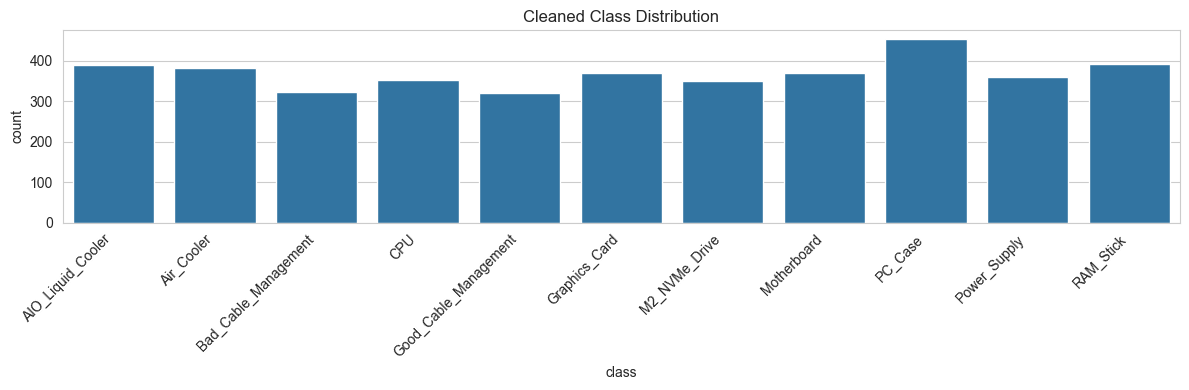

In [5]:
manifest = clean_dataset_once(RAW_DIR, CLEANED_DIR, force_reclean=FORCE_RECLEAN)

print("Cleaning summary")
print("- input images:", manifest["num_input_images"])
print("- kept images:", manifest["num_kept_images"])
print("- removed corrupt:", manifest["num_removed_corrupt"])
print("- removed duplicates:", manifest["num_removed_duplicates"])

class_count_df = pd.DataFrame(
    sorted(manifest["class_counts"].items()), columns=["class", "count"]
)
display(class_count_df)

plt.figure(figsize=(12, 4))
sns.barplot(data=class_count_df, x="class", y="count")
plt.xticks(rotation=45, ha="right")
plt.title("Cleaned Class Distribution")
plt.tight_layout()
plt.show()

## 3) Fixed Stratified Train/Validation/Test Split (Reused for All Models)

In [6]:
split_csv = CLEANED_DIR / "splits.csv"

if split_csv.exists():
    split_df = pd.read_csv(split_csv)
    print("Reusing existing split file:", split_csv)
else:
    cleaned_files = sorted(get_image_files(CLEANED_DIR))
    records = [{"path": str(p), "label": p.parent.name} for p in cleaned_files]
    full_df = pd.DataFrame(records)

    train_val_df, test_df = train_test_split(
        full_df,
        test_size=TEST_PCT,
        random_state=RANDOM_SEED,
        stratify=full_df["label"],
    )

    val_relative = VALID_PCT / (1.0 - TEST_PCT)
    train_df, valid_df = train_test_split(
        train_val_df,
        test_size=val_relative,
        random_state=RANDOM_SEED,
        stratify=train_val_df["label"],
    )

    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()

    train_df["split"] = "train"
    valid_df["split"] = "valid"
    test_df["split"] = "test"

    split_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)
    split_df = split_df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
    split_df.to_csv(split_csv, index=False)

print(split_df.head())

print("\nSplit counts:")
display(split_df["split"].value_counts())

print("\nClass counts per split:")
display(pd.crosstab(split_df["label"], split_df["split"]))

train_paths = set(split_df.loc[split_df["split"] == "train", "path"])
valid_paths = set(split_df.loc[split_df["split"] == "valid", "path"])
test_paths = set(split_df.loc[split_df["split"] == "test", "path"])

print("\nLeakage check intersections (must all be 0):")
print("train ∩ valid:", len(train_paths & valid_paths))
print("train ∩ test:", len(train_paths & test_paths))
print("valid ∩ test:", len(valid_paths & test_paths))

                                                         path          label  \
0     cleaned\Air_Cooler\847bdcaafe8e454f887b4ccfb6e0083f.jpg     Air_Cooler   
1        cleaned\PC_Case\0096d04984a24875918bdef39bb1feeb.jpg        PC_Case   
2   cleaned\Power_Supply\383500b206e64ce6ab37072afd837442.jpg   Power_Supply   
3  cleaned\Graphics_Card\d29b0cf291ed45dd9c85d9db5c72dc56.jpg  Graphics_Card   
4     cleaned\Air_Cooler\89146e898d6041a29a38909b4029b9f3.jpg     Air_Cooler   

   split  
0  train  
1  train  
2  train  
3  train  
4  train  

Split counts:


split
train    3243
test      406
valid     406
Name: count, dtype: int64


Class counts per split:


split,test,train,valid
label,,,
AIO_Liquid_Cooler,39,310,39
Air_Cooler,38,305,38
Bad_Cable_Management,32,258,32
CPU,35,281,36
Good_Cable_Management,32,256,32
Graphics_Card,37,296,37
M2_NVMe_Drive,35,279,35
Motherboard,37,296,37
PC_Case,46,361,45



Leakage check intersections (must all be 0):
train ∩ valid: 0
train ∩ test: 0
valid ∩ test: 0


DataLoaders ready. Vocab: ['AIO_Liquid_Cooler', 'Air_Cooler', 'Bad_Cable_Management', 'CPU', 'Good_Cable_Management', 'Graphics_Card', 'M2_NVMe_Drive', 'Motherboard', 'PC_Case', 'Power_Supply', 'RAM_Stick']
DataLoaders batch size: 16


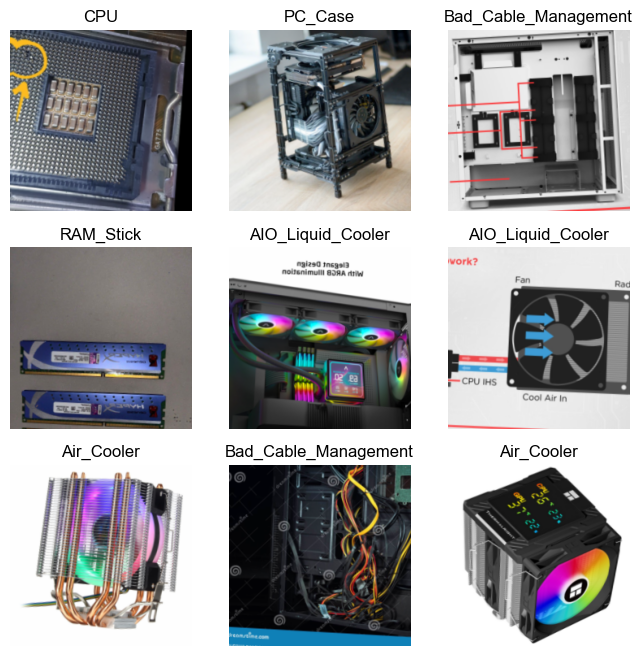

In [7]:
def make_dls_from_split(split_df: pd.DataFrame, bs: int = BS, img_size: int = IMG_SIZE):
    train_valid_df = split_df[split_df["split"] != "test"].reset_index(drop=True).copy()
    valid_idx = train_valid_df.index[train_valid_df["split"] == "valid"].tolist()

    dblock = DataBlock(
        blocks=(ImageBlock, CategoryBlock),
        get_x=ColReader("path"),
        get_y=ColReader("label"),
        splitter=IndexSplitter(valid_idx),
        item_tfms=[Resize(img_size)],
        batch_tfms=[
            *aug_transforms(
                mult=AUG_MULT,
                max_rotate=AUG_MAX_ROTATE,
                max_zoom=AUG_MAX_ZOOM,
                max_warp=AUG_MAX_WARP,
                p_affine=AUG_P_AFFINE,
                p_lighting=AUG_P_LIGHTING,
            ),
            Normalize.from_stats(*imagenet_stats),
        ],
    )

    dls = dblock.dataloaders(train_valid_df, bs=bs)
    return dls, train_valid_df


dls, train_valid_df = make_dls_from_split(split_df, bs=BS, img_size=IMG_SIZE)
print("DataLoaders ready. Vocab:", dls.vocab)
print("DataLoaders batch size:", dls.bs)
dls.show_batch(max_n=9, figsize=(8, 8))

## 4) Selected Models and Why

- **ResNet50**: strong and reliable CNN baseline for image classification.
- **EfficientNet-B3**: good accuracy-efficiency balance with compound scaling.
- **ViT-Base-Patch16-224**: transformer architecture that captures global context well.

All three are fine-tuned with the same split, image size, batch size, augmentation policy, and epoch count for fair comparison.

In [ ]:
MODEL_SPECS = [
    {"name": "resnet50", "kind": "vision", "arch": resnet50},
    {"name": "efficientnet_b3", "kind": "timm", "arch": "efficientnet_b3"},
    {"name": "vit_base_patch16_224", "kind": "timm", "arch": "vit_base_patch16_224"},
]

def build_learner(dls, spec):
    if spec["kind"] == "vision":
        learn = vision_learner(dls, spec["arch"], pretrained=True, metrics=[accuracy])
    elif spec["kind"] == "timm":
        if timm_learner is not None:
            learn = timm_learner(dls, spec["arch"], pretrained=True, metrics=[accuracy])
        else:
            learn = vision_learner(dls, spec["arch"], pretrained=True, metrics=[accuracy])
    else:
        raise ValueError(f"Unknown model kind: {spec['kind']}")

    if torch.cuda.is_available():
        learn = learn.to_fp16()
    return learn


def history_dataframe(learn):
    cols = [c for c in learn.recorder.metric_names[1:] if c != "time"]
    hist = pd.DataFrame(learn.recorder.values, columns=cols)
    hist.insert(0, "epoch", np.arange(1, len(hist) + 1))
    return hist


def plot_training_curves(hist_df: pd.DataFrame, model_name: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
    axes[0].plot(hist_df["epoch"], hist_df["valid_loss"], label="valid_loss")
    axes[0].set_title(f"{model_name}: Loss Curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    if "accuracy" in hist_df.columns:
        axes[1].plot(hist_df["epoch"], hist_df["accuracy"], label="valid_accuracy")
        axes[1].set_title(f"{model_name}: Validation Accuracy")
    else:
        axes[1].text(0.5, 0.5, "No accuracy metric found", ha="center", va="center")
        axes[1].set_title(f"{model_name}: Metrics")

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend(loc="lower right") if "accuracy" in hist_df.columns else None

    plt.tight_layout()
    plt.show()


def train_one_model(spec, dls, epochs=EPOCHS):
    name = spec["name"]
    print(f"\nTraining model: {name}")

    learn = build_learner(dls, spec)

    lr = 1e-3
    try:
        lr_find_res = learn.lr_find(suggest_funcs=(valley,))
        lr = float(lr_find_res.valley)
    except Exception as ex:
        print(f"lr_find fallback for {name}: {ex}")

    print(f"Using base LR for {name}: {lr:.2e}")
    learn.fine_tune(epochs, base_lr=lr)

    history = history_dataframe(learn)
    interp = ClassificationInterpretation.from_learner(learn)

    model_file = ARTIFACTS_DIR / f"{name}_weights.pth"
    torch.save(learn.model.state_dict(), model_file)

    export_file = ARTIFACTS_DIR / f"{name}_export.pkl"
    learn.export(export_file)

    return {
        "name": name,
        "learn": learn,
        "history": history,
        "interp": interp,
        "lr": lr,
        "weights_path": str(model_file),
        "export_path": str(export_file),
    }

## 5) Fine-Tune All 3 Models (>=15 Epochs Each)

Run the next three code cells separately:
- Cell 14 trains **ResNet50**
- Cell 15 trains **EfficientNet-B3**
- Cell 16 trains **ViT-Base-Patch16-224**

Each training cell prints epoch-wise progress and then displays:
- training/validation loss curves
- validation accuracy curve
- confusion matrix


Training model: resnet50


<div></div>

Using base LR for resnet50: 2.09e-03


epoch,train_loss,valid_loss,accuracy,time
0,2.298673,1.619098,0.495074,01:22


epoch,train_loss,valid_loss,accuracy,time
0,1.539420,1.288590,0.583744,01:26
1,1.295326,1.276922,0.630542,01:24
2,1.196468,1.243741,0.640394,01:24
3,1.026873,1.189676,0.657635,01:25
4,0.926652,1.171734,0.650246,01:24
5,0.808897,1.108405,0.667488,01:25
6,0.600647,1.198202,0.667488,01:24
7,0.526012,1.264510,0.662562,01:24
8,0.433944,1.269387,0.672414,01:24
9,0.376604,1.226586,0.692118,01:23


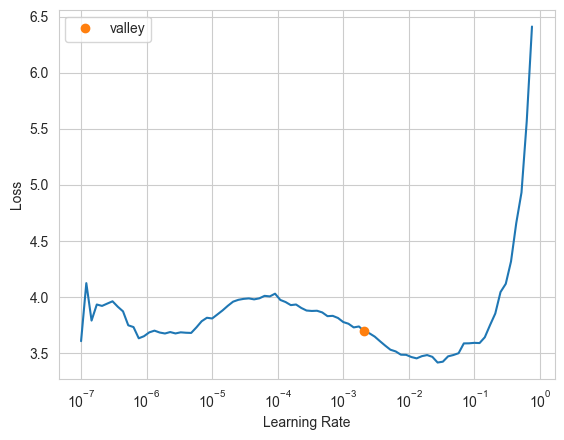

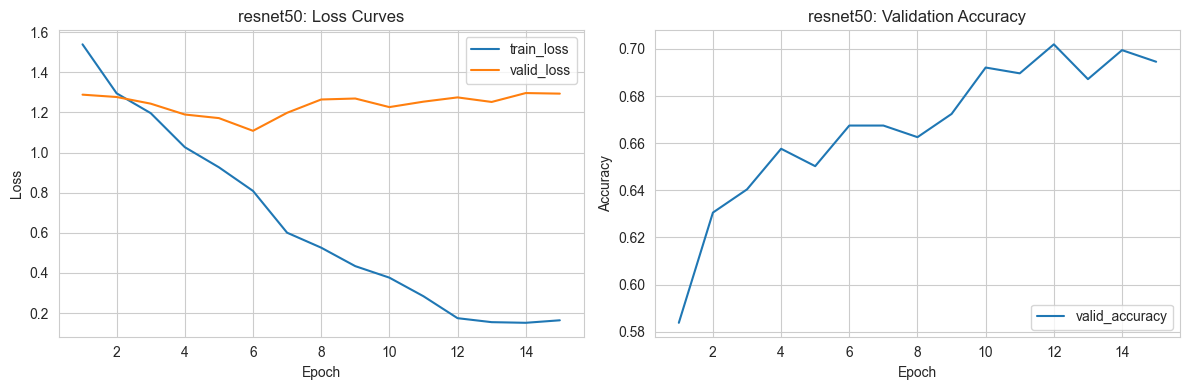

Validation confusion matrix: resnet50


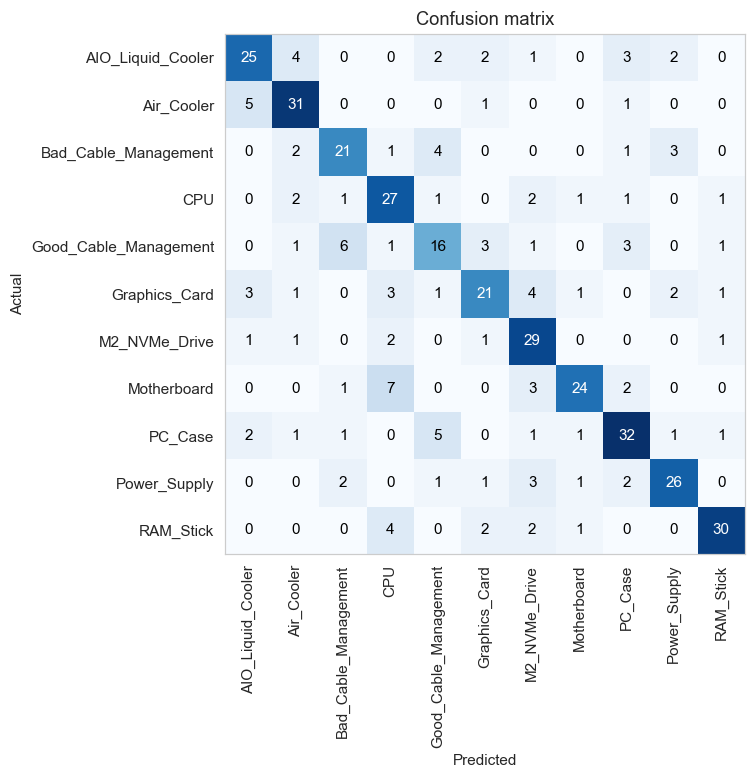


Training model: efficientnet_b3


NameError: name 'timm_learner' is not defined

In [ ]:
results = {}

resnet_spec = next(s for s in MODEL_SPECS if s["name"] == "resnet50")
outcome = train_one_model(resnet_spec, dls, epochs=EPOCHS)
results[resnet_spec["name"]] = outcome

hist = outcome["history"]
plot_training_curves(hist, resnet_spec["name"])

print(f"Validation confusion matrix: {resnet_spec['name']}")
outcome["interp"].plot_confusion_matrix(figsize=(7, 7), dpi=110)
plt.show()

In [ ]:
efficientnet_spec = next(s for s in MODEL_SPECS if s["name"] == "efficientnet_b3")
outcome = train_one_model(efficientnet_spec, dls, epochs=EPOCHS)
results[efficientnet_spec["name"]] = outcome

hist = outcome["history"]
plot_training_curves(hist, efficientnet_spec["name"])

print(f"Validation confusion matrix: {efficientnet_spec['name']}")
outcome["interp"].plot_confusion_matrix(figsize=(7, 7), dpi=110)
plt.show()

In [ ]:
vit_spec = next(s for s in MODEL_SPECS if s["name"] == "vit_base_patch16_224")
outcome = train_one_model(vit_spec, dls, epochs=EPOCHS)
results[vit_spec["name"]] = outcome

hist = outcome["history"]
plot_training_curves(hist, vit_spec["name"])

print(f"Validation confusion matrix: {vit_spec['name']}")
outcome["interp"].plot_confusion_matrix(figsize=(7, 7), dpi=110)
plt.show()

## 6) Model Comparison and Best Model Selection

In [ ]:
comparison_rows = []

for name, out in results.items():
    hist = out["history"]
    best_val_acc = float(hist["accuracy"].max()) if "accuracy" in hist.columns else np.nan
    final_val_loss = float(hist["valid_loss"].iloc[-1])

    # Stability proxy: lower std of epoch-to-epoch change in validation loss is more stable
    val_loss_delta_std = float(hist["valid_loss"].diff().dropna().std()) if len(hist) > 2 else np.nan

    comparison_rows.append(
        {
            "model": name,
            "best_val_accuracy": best_val_acc,
            "final_val_loss": final_val_loss,
            "val_loss_delta_std": val_loss_delta_std,
            "lr_used": out["lr"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(
    by=["best_val_accuracy", "final_val_loss", "val_loss_delta_std"],
    ascending=[False, True, True],
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.iloc[0]["model"]
print(f"Best model selected: {best_model_name}")

## 7) Evaluate Best Model on Full Held-Out Test Split

In [ ]:
best_result = results[best_model_name]
best_learn = best_result["learn"]

test_df = split_df[split_df["split"] == "test"].reset_index(drop=True).copy()
print("Test size:", len(test_df))

test_dl = best_learn.dls.test_dl(test_df, with_labels=True)
probs, targs = best_learn.get_preds(dl=test_dl)
pred_idx = probs.argmax(dim=1).cpu().numpy()
true_idx = targs.cpu().numpy()

labels = list(best_learn.dls.vocab)

overall_acc = accuracy_score(true_idx, pred_idx)
print(f"Overall test accuracy: {overall_acc:.4f}")

p, r, f1, support = precision_recall_fscore_support(
    true_idx, pred_idx, labels=np.arange(len(labels)), zero_division=0
)

class_metrics_df = pd.DataFrame(
    {
        "class": labels,
        "precision": p,
        "recall": r,
        "f1": f1,
        "support": support,
    }
)
display(class_metrics_df.sort_values("class").reset_index(drop=True))

report = classification_report(true_idx, pred_idx, target_names=labels, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
display(report_df)

cm = confusion_matrix(true_idx, pred_idx, labels=np.arange(len(labels)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap="Blues")
plt.title(f"Test Confusion Matrix ({best_model_name})")
plt.tight_layout()
plt.show()

class_metrics_df.to_csv(REPORTS_DIR / "best_model_class_metrics.csv", index=False)
report_df.to_csv(REPORTS_DIR / "best_model_classification_report.csv")

## 8) Export Best Model (FastAI + PyTorch + Optional ONNX)

In [ ]:
best_export_path = ARTIFACTS_DIR / "best_model_export.pkl"
best_weights_path = ARTIFACTS_DIR / "best_model_state_dict.pth"
best_metadata_path = ARTIFACTS_DIR / "best_model_metadata.json"
best_onnx_path = ARTIFACTS_DIR / "best_model.onnx"

best_learn.export(best_export_path)
torch.save(best_learn.model.state_dict(), best_weights_path)

metadata = {
    "best_model_name": best_model_name,
    "classes": labels,
    "num_classes": len(labels),
    "img_size": IMG_SIZE,
    "batch_size": BS,
    "epochs": EPOCHS,
    "test_accuracy": float(overall_acc),
    "created_at": datetime.now().isoformat(timespec="seconds"),
}

with best_metadata_path.open("w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved:")
print("-", best_export_path)
print("-", best_weights_path)
print("-", best_metadata_path)

# Optional ONNX export
onnx_exported = False
try:
    model_cpu = best_learn.model.cpu().eval()
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device="cpu")
    torch.onnx.export(
        model_cpu,
        dummy,
        best_onnx_path,
        input_names=["input"],
        output_names=["logits"],
        opset_version=17,
    )
    onnx_exported = True
except Exception as ex:
    print("ONNX export skipped/failed:", ex)
finally:
    if torch.cuda.is_available():
        best_learn.model.cuda()

print("ONNX exported:", onnx_exported)

## 9) Inference Function + Demo

In [ ]:
inference_learner = load_learner(best_export_path)

def predict_image(image_path, learner=inference_learner):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    pred_class, pred_idx, probs = learner.predict(image_path)
    probs = probs.tolist()

    all_scores = {
        learner.dls.vocab[i]: float(probs[i]) for i in range(len(learner.dls.vocab))
    }
    all_scores = dict(sorted(all_scores.items(), key=lambda kv: kv[1], reverse=True))

    return {
        "image": str(image_path),
        "predicted_class": str(pred_class),
        "predicted_index": int(pred_idx),
        "confidence_scores": all_scores,
    }


demo_samples = split_df.groupby("label")["path"].first().head(3).tolist()

for sample_path in demo_samples:
    out = predict_image(sample_path)
    print("\nImage:", out["image"])
    print("Predicted class:", out["predicted_class"])

    top5 = list(out["confidence_scores"].items())[:5]
    print("Top-5 confidences:")
    for cls_name, score in top5:
        print(f"  {cls_name}: {score:.4f}")

    # Full confidence scores for all 11 classes
    full_scores_df = pd.DataFrame(
        out["confidence_scores"].items(), columns=["class", "confidence"]
    )
    display(full_scores_df)

## 10) Final Summary

- Cleaning is done once and tracked in `cleaned/cleaning_manifest.json`.
- Same split and training settings are reused across all 3 models for fair comparison.
- Best model is selected from validation metrics and evaluated on held-out test split.
- Artifacts for deployment are saved to `artifacts/`.
- Inference utility returns predicted class and confidence scores for all classes.